# Greedy methods

GDFS, DIME, and EDDI

## imports and settings

Choose the patient counts and seed, and load the evidence and diagnosis descriptions.

In [28]:
from pathlib import Path
import pandas as pd
import torch
import ast

trainNo = 2000
validNo = 500
testNo = 500
rndseed = 42


project = Path(r"C:\Users\ragha\OneDrive\Desktop\SDP-Sequential-Diagnosis")
data = project / "data"
evidences = pd.read_json(data / "release_evidences.json",orient="index")

conditions = pd.read_json( data / "release_conditions.json", orient="index")

print("Evidence types:", len(evidences))
print("Diagnoses:", len(conditions))

Evidence types: 223
Diagnoses: 49


## load patient data

Read the training, validation, and test files and select the patients for this experiment. Use the same seed and patient counts when comparing methods.

In [29]:

columns = ["PATHOLOGY", "EVIDENCES", "INITIAL_EVIDENCE"]

train_df = pd.read_csv(
    data / "release_train_patients.zip",
    usecols=columns
)

validation_df = pd.read_csv(
    data / "release_validate_patients.zip",
    usecols=columns
)

test_df = pd.read_csv(
    data / "release_test_patients.zip",
    usecols=columns
)

train_df = train_df.sample(n=min(trainNo, len(train_df)), random_state=rndseed)
validation_df = validation_df.sample( n=min(validNo, len(validation_df)), random_state=rndseed)
test_df = test_df.sample( n=min(testNo, len(test_df)), random_state=rndseed)

print("Train:", len(train_df), "Validation:", len(validation_df), "Test:", len(test_df))
train_df.head(3)

Train: 2000 Validation: 500 Test: 500


,PATHOLOGY,EVIDENCES,INITIAL_EVIDENCE
625083,Allergic sinusitis,"['E_86', 'E_87', 'E_124', 'E_169', 'E_181', 'E...",E_169
469074,Myasthenia gravis,"['E_28', 'E_38', 'E_52', 'E_63', 'E_65', 'E_17...",E_38
69338,Influenza,"['E_50', 'E_53', 'E_54_@_V_161', 'E_54_@_V_183...",E_129


### define feature columns
Create a column for each symptom or possible answer.
Use the same columns across the training, validation, and test splits.

In [30]:
feature_columns = []
default_answers = {}

for row, evidence in evidences.iterrows():
    evidence_name = evidence["name"]

    if evidence["data_type"] == "B":
        feature_columns.append(evidence_name)

    else:
        for answer in evidence["possible-values"]:
            feature_columns.append(f"{evidence_name}_@_{answer}")

        default_answers[evidence_name] =(f"{evidence_name}_@_{evidence['default_value']}")

print("Number of feature columns:", len(feature_columns))

Number of feature columns: 972


### encode patient evidence

Use 1 for recorded symptoms or answers and 0 for the others.
For unrecorded nonbinary evidence, use the dataset's default answer.

In [31]:
reformat = []

for frame in [train_df, validation_df, test_df]:
    features = pd.DataFrame(
        0,
        index=frame.index,
        columns=feature_columns,
        dtype="float32"
    )

    for index, row in frame.iterrows():
        patient_evidences = ast.literal_eval(row["EVIDENCES"])
        recorded_evidence = []

        for answer in patient_evidences:
            assert answer in features.columns, f"Unknown evidence: {answer}"

            features.at[index, answer] = 1

            evidence_name = answer.split("_@_", 1)[0]
            recorded_evidence.append(evidence_name)

        # Add default answers for unrecorded nonbinary evidence.
        for evidence_name, default_answer in default_answers.items():
            if evidence_name not in recorded_evidence:
                features.at[index, default_answer] = 1

    reformat.append(features)

train_features, validation_features, test_features = reformat

print("Training:", train_features.shape)
print("Validation:", validation_features.shape)
print("Test:", test_features.shape)

Training: (2000, 972)
Validation: (500, 972)
Test: (500, 972)


### encode diagnosis labels

Convert PATHOLOGY into one-hot encoding.

In [32]:
diagnoses = sorted(conditions["cond-name-eng"].unique())

reformat = []

for patient in [train_df, validation_df, test_df]:
    assert patient["PATHOLOGY"].isin(diagnoses).all(), "Unknown diagnosis found"

    labels = pd.get_dummies(patient["PATHOLOGY"])
    labels = labels.reindex(columns=diagnoses, fill_value=0)
    labels = labels.astype("float32")

    reformat.append(labels)

train_labels, validation_labels, test_labels = reformat

print("Training labels:", train_labels.shape)
print("Validation labels:", validation_labels.shape)
print("Test labels:", test_labels.shape)

Training labels: (2000, 49)
Validation labels: (500, 49)
Test labels: (500, 49)


## convert data to PyTorch tensors

Convert the encoded tables to the numeric arrays used by the models. Inputs contain evidence values; targets contain the known diagnoses.

In [33]:
train_inputs = torch.tensor(train_features.to_numpy(), dtype=torch.float32)
train_targets = torch.tensor(train_labels.to_numpy(), dtype=torch.float32)

validation_inputs = torch.tensor(validation_features.to_numpy(), dtype=torch.float32)
validation_targets = torch.tensor(validation_labels.to_numpy(), dtype=torch.float32)

test_inputs = torch.tensor(test_features.to_numpy(), dtype=torch.float32)
test_targets = torch.tensor(test_labels.to_numpy(), dtype=torch.float32)

print("Training:", train_inputs.shape, train_targets.shape)
print("Validation:", validation_inputs.shape, validation_targets.shape)
print("Test:", test_inputs.shape, test_targets.shape)

Training: torch.Size([2000, 972]) torch.Size([2000, 49])
Validation: torch.Size([500, 972]) torch.Size([500, 49])
Test: torch.Size([500, 972]) torch.Size([500, 49])


## prepare training batches

Pair each patient's evidence with their diagnosis and group patients into batches. Models can use these batches during training and evaluation; the tensors are also available for methods that use them directly.

In [34]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 128
reformat = []

for inputs, targets in [
    (train_inputs, train_targets),
    (validation_inputs, validation_targets),
    (test_inputs, test_targets)
]:
    patients = TensorDataset(inputs, targets)
    reformat.append(patients)

train_dataset, validation_dataset, test_dataset = reformat

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

validation_loader = DataLoader(validation_dataset, batch_size=batch_size)

test_loader = DataLoader(test_dataset,batch_size=batch_size)

## GDFS

### set up the diagnosis model

Create the model that predicts a diagnosis from the available evidence. The input includes evidence values and indicators showing which evidence is visible.

In [35]:
import sys

sys.path.insert(0, str(project / "AFA_bench"))

from torch import nn
from torchrl.modules import MLP
from afabench.core.utils import set_seed
from afabench.components.methods.discriminative.common.models import MaskingPretrainer
from afabench.components.methods.discriminative.common.utils import MaskLayer

set_seed(rndseed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 1

predictor = MLP(
    in_features=train_inputs.shape[1] * 2,
    out_features=train_targets.shape[1],
    num_cells=[128, 128],
    activation_class=nn.ReLU,
    dropout=0.3
)

mask = MaskLayer(append=True)
pretrainer = MaskingPretrainer(predictor, mask).to(device)

### pretrain the diagnosis model

Train with some evidence hidden so the model learns to predict diagnoses from incomplete information.

In [36]:
counts = train_targets.sum(dim=0)
weights = len(train_targets) / counts.clamp(min=1)
epochs = 20
pretrainer.fit(
    train_loader,
    validation_loader,
    lr=0.001,
    nepochs=epochs,
    loss_fn=nn.CrossEntropyLoss(weight=weights.to(device)),
    patience=5,
    min_mask=0.0,
    max_mask=0.9,
    verbose=True
)

--------Epoch 1--------
Train loss = 3.9083

Val loss = 3.8840

--------Epoch 2--------
Train loss = 3.9110

Val loss = 3.8831

--------Epoch 3--------
Train loss = 3.8869

Val loss = 3.8808

--------Epoch 4--------
Train loss = 3.8774

Val loss = 3.8771

--------Epoch 5--------
Train loss = 3.8798

Val loss = 3.8199

--------Epoch 6--------
Train loss = 3.8512

Val loss = 3.8312

--------Epoch 7--------
Train loss = 3.8363

Val loss = 3.8004

--------Epoch 8--------
Train loss = 3.7930

Val loss = 3.8144

--------Epoch 9--------
Train loss = 3.7448

Val loss = 3.5038

--------Epoch 10--------
Train loss = 3.6049

Val loss = 3.3067

--------Epoch 11--------
Train loss = 3.4852

Val loss = 3.1925

--------Epoch 12--------
Train loss = 3.2478

Val loss = 2.8097

--------Epoch 13--------
Train loss = 3.0301

Val loss = 3.0791

--------Epoch 14--------
Train loss = 2.7106

Val loss = 2.6128

--------Epoch 15--------
Train loss = 2.7332

Val loss = 1.8488

--------Epoch 16--------
Train los

### set up the evidence selector

starts with all evidence hidden and reveals one encoded column per selection.

In [37]:
from afabench.components.initializers import ZeroInitializer
from afabench.components.unmaskers import DirectUnmasker
from afabench.components.methods.discriminative.gdfs.afa_methods import GreedyDynamicSelection

set_seed(rndseed)

selector = MLP(
    in_features=train_inputs.shape[1] * 2,
    out_features=train_inputs.shape[1],
    num_cells=[128, 128],
    activation_class=nn.ReLU,
    dropout=0.3
)

initializer = ZeroInitializer()
unmasker = DirectUnmasker()

gdfs = GreedyDynamicSelection(
    selector=selector,
    predictor=predictor,
    mask_layer=mask,
    initializer=initializer,
    unmasker=unmasker
).to(device)

### train GDFS

Train the evidence selector and diagnosis model together. GDFS learns which evidence to reveal next, using a budget of 20 encoded features per patient. Training uses 4 epochs per stage across 5 stages, for a maximum of 20 epochs.

In [38]:
import time

epochs = 4
max_features = 20

start = time.perf_counter()

gdfs.fit(
    train_loader,
    validation_loader,
    lr=0.001,
    nepochs=epochs,
    max_features=max_features,
    loss_fn=nn.CrossEntropyLoss(weight=weights.to(device)),
    patience=5,
    temp_steps=5,
    verbose=True
)

training_time = time.perf_counter() - start

print("Training time (minutes):", round(training_time / 60, 2))

Starting training with temp = 1.0000

--------Epoch 1 (1 total)--------
Val loss = 3.7617, Zero-temp loss = 3.7645

--------Epoch 2 (2 total)--------
Val loss = 3.3778, Zero-temp loss = 3.3881

--------Epoch 3 (3 total)--------
Val loss = 2.9980, Zero-temp loss = 3.0138

--------Epoch 4 (4 total)--------
Val loss = 2.7720, Zero-temp loss = 2.7914

Stopping temp = 1.0000 at epoch 4

Starting training with temp = 0.5623

--------Epoch 1 (5 total)--------
Val loss = 2.6814, Zero-temp loss = 2.6984

--------Epoch 2 (6 total)--------
Val loss = 2.5398, Zero-temp loss = 2.5561

--------Epoch 3 (7 total)--------
Val loss = 2.4449, Zero-temp loss = 2.4629

--------Epoch 4 (8 total)--------
Val loss = 2.3447, Zero-temp loss = 2.3614

Stopping temp = 0.5623 at epoch 4

Starting training with temp = 0.3162

--------Epoch 1 (9 total)--------
Val loss = 2.3087, Zero-temp loss = 2.3206

--------Epoch 2 (10 total)--------
Val loss = 2.2507, Zero-temp loss = 2.2639

--------Epoch 3 (11 total)--------


### check validation accuracy



In [39]:
from afabench.components.methods.discriminative.gdfs.afa_methods import GDFSAFAMethod
from afabench.evaluation.eval import eval_afa_method

gdfs.eval()

evaluation_model = GDFSAFAMethod(
    selector=gdfs.selector,
    predictor=gdfs.predictor,
    device=device
)

validation_dataset.feature_shape = validation_inputs.shape[1:]

with torch.inference_mode():
    validation_results = eval_afa_method(
        afa_action_fn=evaluation_model.act,
        afa_unmask_fn=unmasker.unmask,
        n_selection_choices=train_inputs.shape[1],
        afa_initialize_fn=initializer.initialize,
        dataset=validation_dataset,
        builtin_afa_predict_fn=evaluation_model.predict,
        device=device,
        selection_budget=max_features,
        batch_size=batch_size
    )

# Keep the final prediction for each patient.
final_predictions = validation_results[
    validation_results["action_performed"] == 0
]

assert len(final_predictions) == len(validation_dataset)

accuracy = (
    final_predictions["builtin_predicted_class"]
    == final_predictions["true_class"]
).mean()

print(f"Validation accuracy ({max_features} acquired features): {accuracy:.2%}")

100%|██████████| 4/4 [00:02<00:00,  1.88it/s]

Validation accuracy (20 acquired features): 54.80%


### test GDFS


In [40]:
gdfs.eval()

test_dataset.feature_shape = test_inputs.shape[1:]

with torch.inference_mode():
    test_results = eval_afa_method(
        afa_action_fn=evaluation_model.act,
        afa_unmask_fn=unmasker.unmask,
        n_selection_choices=train_inputs.shape[1],
        afa_initialize_fn=initializer.initialize,
        dataset=test_dataset,
        builtin_afa_predict_fn=evaluation_model.predict,
        device=device,
        selection_budget=max_features,
        batch_size=batch_size
    )

final_predictions = test_results[test_results["action_performed"] == 0]

assert len(final_predictions) == len(test_dataset)

test_accuracy = ( final_predictions["builtin_predicted_class"] == final_predictions["true_class"]).mean()

print(f"Test accuracy ({max_features} acquired features): {test_accuracy:.2%}")

100%|██████████| 4/4 [00:01<00:00,  3.21it/s]

Test accuracy (20 acquired features): 54.00%


### save GDFS results


In [41]:
import json

run_name = "gdfs_run1"
output = project / "afabench" / "outputs" / run_name
output.mkdir(parents=True, exist_ok=True)

# Use the trained networks and record their sizes for loading later.
saved_model = GDFSAFAMethod(
    selector=gdfs.selector,
    predictor=gdfs.predictor,
    device=device,
    d_in=train_inputs.shape[1],
    d_out=train_targets.shape[1],
    n_selections=train_inputs.shape[1]
)

saved_model.save(output / "model")

settings = {
    "seed": rndseed,
    "batch_size": batch_size,
    "max_features": max_features,
    "train_patients": len(train_dataset),
    "validation_patients": len(validation_dataset),
    "test_patients": len(test_dataset),
    "feature_columns": feature_columns,
    "diagnoses": diagnoses,
    "default_answers": default_answers
}

with open(output / "settings.json", "w", encoding="utf-8") as file:
    json.dump(settings, file, indent=2)

metrics = {
    "validation_accuracy": float(accuracy),
    "test_accuracy": float(test_accuracy),
    "training_time_minutes": training_time / 60
}

with open(output / "metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

test_predictions = test_results[
    test_results["action_performed"] == 0
]
test_predictions.to_csv(output / "test_predictions.csv", index=False)

print("Saved to:", output)

Saved to: C:\Users\ragha\OneDrive\Desktop\SDP-Sequential-Diagnosis\afabench\outputs\gdfs_run1


### result analysis

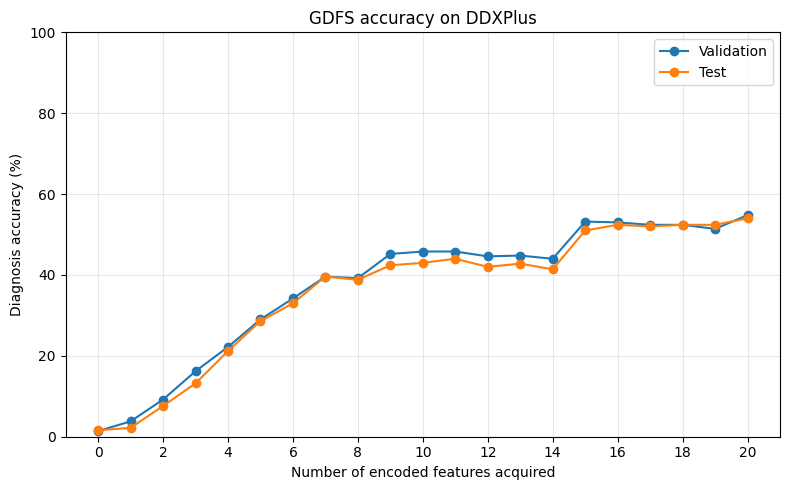

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for name, results in [
    ("Validation", validation_results),
    ("Test", test_results)
]:
    chart = results.copy()

    chart["features"] = chart["prev_selections_performed"].apply(len)
    chart["correct"] = (
        chart["builtin_predicted_class"] == chart["true_class"]
    )

    scores = chart.groupby("features")["correct"].mean() * 100

    plt.plot(scores.index, scores.values, marker="o", label=name)

plt.title("GDFS accuracy on DDXPlus")
plt.xlabel("Number of encoded features acquired")
plt.ylabel("Diagnosis accuracy (%)")
plt.xticks(range(0, max_features + 1, 2))
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(output / "accuracy_by_features.png", dpi=300)
plt.show()

In [46]:
diagnosis_names = dict(enumerate(diagnoses))

results = pd.DataFrame()

results["true_diagnosis"] = (
    test_predictions["true_class"].map(diagnosis_names)
)

results["predicted_diagnosis"] = (
    test_predictions["builtin_predicted_class"].map(diagnosis_names)
)

results["correct"] = (
    results["true_diagnosis"] == results["predicted_diagnosis"]
)

results.to_json(
    output / "test_results.json",
    orient="records",
    indent=2,
    force_ascii=False
)

display(results.head(5))

,true_diagnosis,predicted_diagnosis,correct
2560,Bronchospasm / acute asthma exacerbation,Acute COPD exacerbation / infection,False
2561,Acute dystonic reactions,Acute COPD exacerbation / infection,False
2562,Chronic rhinosinusitis,Chronic rhinosinusitis,True
2563,HIV (initial infection),HIV (initial infection),True
2564,Panic attack,Panic attack,True


## DIME

DIME is another greedy method. It learns to estimate how useful each feature would be for predicting the diagnosis, then chooses the next feature using those estimates.

### set up the diagnosis model

Create a fresh diagnosis model for DIME. The previous model has already been updated by GDFS, so we start this experiment separately.

In [47]:
from afabench.components.methods.discriminative.dime.afa_methods import CMIEstimator, DIMEAFAMethod
from afabench.components.methods.discriminative.common.utils import tie_first_k_linears_by_module


set_seed(rndseed)

dime_pretrain_epochs = 20
dime_epochs = 20
dime_max_features = 20

dime_output = project / "afabench" / "outputs" / "dime_run1"
dime_output.mkdir(parents=True, exist_ok=True)

dime_predictor = MLP(
    in_features=train_inputs.shape[1] * 2,
    out_features=train_targets.shape[1],
    num_cells=[128, 128],
    activation_class=nn.ReLU,
    dropout=0.3
)

dime_mask = MaskLayer(append=True)
dime_pretrainer = MaskingPretrainer(dime_predictor, dime_mask).to(device)

### pretrain the diagnosis model



In [48]:
dime_pretrainer.fit(
    train_loader,
    validation_loader,
    lr=0.001,
    nepochs=dime_pretrain_epochs,
    loss_fn=nn.CrossEntropyLoss(weight=weights.to(device)),
    patience=5,
    min_mask=0.0,
    max_mask=0.9,
    verbose=True
)

--------Epoch 1--------
Train loss = 3.9083

Val loss = 3.8840

--------Epoch 2--------
Train loss = 3.9110

Val loss = 3.8831

--------Epoch 3--------
Train loss = 3.8869

Val loss = 3.8808

--------Epoch 4--------
Train loss = 3.8774

Val loss = 3.8771

--------Epoch 5--------
Train loss = 3.8798

Val loss = 3.8199

--------Epoch 6--------
Train loss = 3.8512

Val loss = 3.8312

--------Epoch 7--------
Train loss = 3.8363

Val loss = 3.8004

--------Epoch 8--------
Train loss = 3.7930

Val loss = 3.8144

--------Epoch 9--------
Train loss = 3.7448

Val loss = 3.5038

--------Epoch 10--------
Train loss = 3.6049

Val loss = 3.3067

--------Epoch 11--------
Train loss = 3.4852

Val loss = 3.1925

--------Epoch 12--------
Train loss = 3.2478

Val loss = 2.8097

--------Epoch 13--------
Train loss = 3.0301

Val loss = 3.0791

--------Epoch 14--------
Train loss = 2.7106

Val loss = 2.6128

--------Epoch 15--------
Train loss = 2.7332

Val loss = 1.8488

--------Epoch 16--------
Train los

### set up the feature-scoring model


In [52]:
set_seed(rndseed)

dime_values = MLP(
    in_features=train_inputs.shape[1] * 2,
    out_features=train_inputs.shape[1],
    num_cells=[128, 128],
    activation_class=nn.ReLU,
    dropout=0.3
).to(device)

tie_first_k_linears_by_module(dime_predictor, dime_values, k=2)

dime = CMIEstimator(
    value_network=dime_values,
    predictor=dime_predictor,
    mask_layer=dime_mask,
    initializer=initializer,
    unmasker=unmasker
).to(device)

### train DIME

train the feature-scoring model and diagnosis model together
it sometimes explores random features to learn their usefulness

In [53]:
dime_weights = (weights / weights.sum()).to(device)

start = time.perf_counter()

dime.fit(
    train_loader,
    validation_loader,
    lr=0.001,
    nepochs=dime_epochs,
    max_features=dime_max_features,
    eps=0.05,
    loss_fn=nn.CrossEntropyLoss(weight=dime_weights, reduction="none"),
    val_loss_fn=nn.CrossEntropyLoss(weight=dime_weights),
    val_loss_mode="min",
    patience=5,
    eps_decay=0.2,
    eps_steps=10,
    verbose=True
)

dime_training_time = time.perf_counter() - start

print("Training time (minutes):", round(dime_training_time / 60, 2))

c:\Users\ragha\OneDrive\Desktop\SDP-Sequential-Diagnosis\AFA_bench\.venv\Lib\site-packages\torch\_compile.py:51: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


--------Epoch 1--------
Loss Val/Mean = 0.03198692947626114
Perf Val/Mean = 3.8815808296203613
Loss Val/Final = 0.03200896084308624
Perf Val/Final = 3.8842544555664062
Eps Value = 0.05

--------Epoch 2--------
Loss Val/Mean = 0.03206897899508476
Perf Val/Mean = 3.891537666320801
Loss Val/Final = 0.032069988548755646
Perf Val/Final = 3.891660213470459
Eps Value = 0.05

--------Epoch 3--------
Loss Val/Mean = 0.03198879212141037
Perf Val/Mean = 3.881807565689087
Loss Val/Final = 0.031973037868738174
Perf Val/Final = 3.8798954486846924
Eps Value = 0.05

--------Epoch 4--------
Loss Val/Mean = 0.031830985099077225
Perf Val/Mean = 3.862657070159912
Loss Val/Final = 0.03216329962015152
Perf Val/Final = 3.9029834270477295
Eps Value = 0.05

--------Epoch 5--------
Loss Val/Mean = 0.031908996403217316
Perf Val/Mean = 3.872124195098877
Loss Val/Final = 0.03256448730826378
Perf Val/Final = 3.9516665935516357
Eps Value = 0.05

--------Epoch 6--------
Loss Val/Mean = 0.03311730548739433
Perf Val/Me

### check validation and test accuracy



In [54]:
dime.eval()

dime_model = DIMEAFAMethod(
    value_network=dime.value_network,
    predictor=dime.predictor,
    device=device,
    d_in=train_inputs.shape[1],
    d_out=train_targets.shape[1],
    n_selections=train_inputs.shape[1]
)

dime_results = []
dime_metrics = {}

for name, patients in [
    ("validation", validation_dataset),
    ("test", test_dataset)
]:
    patients.feature_shape = train_inputs.shape[1:]

    with torch.inference_mode():
        results = eval_afa_method(
            afa_action_fn=dime_model.act,
            afa_unmask_fn=unmasker.unmask,
            n_selection_choices=train_inputs.shape[1],
            afa_initialize_fn=initializer.initialize,
            dataset=patients,
            builtin_afa_predict_fn=dime_model.predict,
            device=device,
            selection_budget=dime_max_features,
            batch_size=batch_size
        )

    predictions = results[results["action_performed"] == 0]
    assert len(predictions) == len(patients)

    score = (
        predictions["builtin_predicted_class"] == predictions["true_class"]
    ).mean()

    dime_metrics[f"{name}_accuracy"] = float(score)
    dime_results.append(results)

    print(f"{name.capitalize()} accuracy: {score:.2%}")

dime_validation_results, dime_test_results = dime_results

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:02<00:00,  1.95it/s]


Validation accuracy: 2.40%


100%|██████████| 4/4 [00:01<00:00,  2.42it/s]

Test accuracy: 3.20%


### save DIME results

Save the trained model, experiment settings, and accuracy results for comparison with the other algorithms.

In [55]:
dime_model.save(dime_output / "model")

dime_settings = {
    "method": "DIME",
    "seed": rndseed,
    "batch_size": batch_size,
    "pretraining_epoch_limit": dime_pretrain_epochs,
    "training_epoch_limit": dime_epochs,
    "max_features": dime_max_features,
    "train_patients": len(train_dataset),
    "validation_patients": len(validation_dataset),
    "test_patients": len(test_dataset),
    "feature_columns": feature_columns,
    "diagnoses": diagnoses,
    "default_answers": default_answers
}

with open(dime_output / "settings.json", "w", encoding="utf-8") as file:
    json.dump(dime_settings, file, indent=2)

dime_metrics["training_time_minutes"] = dime_training_time / 60

with open(dime_output / "metrics.json", "w", encoding="utf-8") as file:
    json.dump(dime_metrics, file, indent=2)

dime_test_predictions = dime_test_results[
    dime_test_results["action_performed"] == 0
]
dime_test_predictions.to_csv(
    dime_output / "test_predictions.csv", index=False
)

print("Saved to:", dime_output)

Saved to: C:\Users\ragha\OneDrive\Desktop\SDP-Sequential-Diagnosis\afabench\outputs\dime_run1


### preview test predictions

Show the first five patients with their true and predicted diagnoses, and save the readable predictions as JSON.

In [56]:
diagnosis_names = dict(enumerate(diagnoses))

dime_predictions = pd.DataFrame()

dime_predictions["true_diagnosis"] = (
    dime_test_predictions["true_class"].map(diagnosis_names)
)

dime_predictions["predicted_diagnosis"] = (
    dime_test_predictions["builtin_predicted_class"].map(diagnosis_names)
)

dime_predictions["correct"] = (
    dime_predictions["true_diagnosis"]
    == dime_predictions["predicted_diagnosis"]
)

dime_predictions.to_json(
    dime_output / "test_results.json",
    orient="records",
    indent=2,
    force_ascii=False
)

display(dime_predictions.head(5))

,true_diagnosis,predicted_diagnosis,correct
2560,Bronchospasm / acute asthma exacerbation,Myocarditis,False
2561,Acute dystonic reactions,Myocarditis,False
2562,Chronic rhinosinusitis,Myocarditis,False
2563,HIV (initial infection),Myocarditis,False
2564,Panic attack,Myocarditis,False


### plot DIME accuracy

Show how diagnosis accuracy changes as DIME acquires more features.

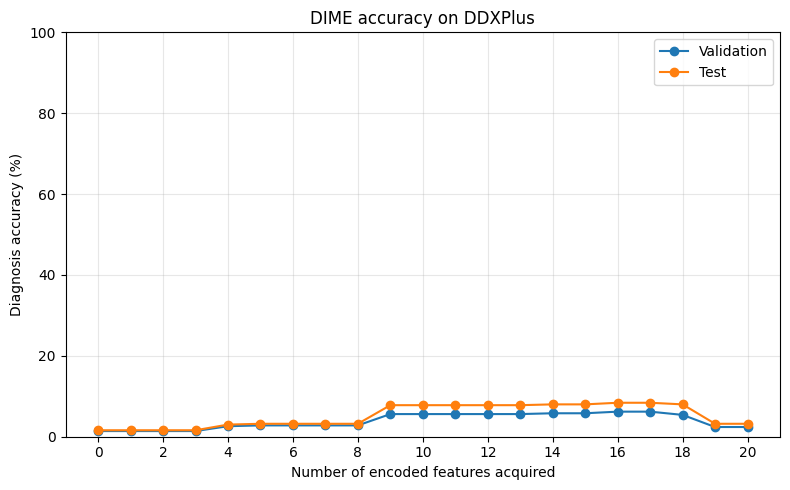

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for name, results in [
    ("Validation", dime_validation_results),
    ("Test", dime_test_results)
]:
    chart = results.copy()

    chart["features"] = chart["prev_selections_performed"].apply(len)
    chart["correct"] = (
        chart["builtin_predicted_class"] == chart["true_class"]
    )

    scores = chart.groupby("features")["correct"].mean() * 100

    plt.plot(scores.index, scores.values, marker="o", label=name)

plt.title("DIME accuracy on DDXPlus")
plt.xlabel("Number of encoded features acquired")
plt.ylabel("Diagnosis accuracy (%)")
plt.xticks(range(0, dime_max_features + 1, 2))
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(dime_output / "accuracy_by_features.png", dpi=300)
plt.show()

## EDDI

EDDI estimates possible values for missing evidence and checks which feature would provide the most useful information for predicting the diagnosis.

We use AFABench's external-classifier variant, with a separate diagnosis model.

### set up the diagnosis model


In [58]:
import lightning as pl

from afabench.components.classifiers.models import MaskedMLPClassifier
from afabench.components.classifiers import WrappedMaskedMLPClassifier
from afabench.components.methods.generative.eddi.afa_methods import EDDIAFAMethod
from afabench.components.methods.rl.odin.models import (
    PointNet, PointNetType, PartialVAE, ODINPretrainingModel
)

set_seed(rndseed)

eddi_epochs = 20
eddi_max_features = 20
eddi_samples = 4

eddi_output = project / "afabench" / "outputs" / "eddi_run1"
eddi_output.mkdir(parents=True, exist_ok=True)

eddi_classifier_model = MaskedMLPClassifier(
    n_features=train_inputs.shape[1],
    n_classes=train_targets.shape[1],
    num_cells=(128, 128),
    dropout=0.3
).to(device)

eddi_classifier_pretrainer = MaskingPretrainer(
    eddi_classifier_model.classifier,
    MaskLayer(append=True)
).to(device)

c:\Users\ragha\OneDrive\Desktop\SDP-Sequential-Diagnosis\AFA_bench\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### train the diagnosis model


In [59]:
start = time.perf_counter()

eddi_classifier_pretrainer.fit(
    train_loader,
    validation_loader,
    lr=0.001,
    nepochs=eddi_epochs,
    loss_fn=nn.CrossEntropyLoss(weight=weights.to(device)),
    patience=5,
    min_mask=0.0,
    max_mask=0.9,
    verbose=True
)

eddi_classifier_time = time.perf_counter() - start

eddi_classifier = WrappedMaskedMLPClassifier(
    module=eddi_classifier_model,
    device=device
)

--------Epoch 1--------
Train loss = 3.9083

Val loss = 3.8840

--------Epoch 2--------
Train loss = 3.9110

Val loss = 3.8831

--------Epoch 3--------
Train loss = 3.8869

Val loss = 3.8808

--------Epoch 4--------
Train loss = 3.8774

Val loss = 3.8771

--------Epoch 5--------
Train loss = 3.8798

Val loss = 3.8199

--------Epoch 6--------
Train loss = 3.8512

Val loss = 3.8312

--------Epoch 7--------
Train loss = 3.8363

Val loss = 3.8004

--------Epoch 8--------
Train loss = 3.7930

Val loss = 3.8144

--------Epoch 9--------
Train loss = 3.7448

Val loss = 3.5038

--------Epoch 10--------
Train loss = 3.6049

Val loss = 3.3067

--------Epoch 11--------
Train loss = 3.4852

Val loss = 3.1925

--------Epoch 12--------
Train loss = 3.2478

Val loss = 2.8097

--------Epoch 13--------
Train loss = 3.0301

Val loss = 3.0791

--------Epoch 14--------
Train loss = 2.7106

Val loss = 2.6128

--------Epoch 15--------
Train loss = 2.7332

Val loss = 1.8488

--------Epoch 16--------
Train los

### set up the missing-evidence model

A partial variational autoencoder (PVAE) learns to estimate missing evidence from the information already available.

AFABench shares this model with ODIN, which is why these classes come from its ODIN folder.

In [60]:
set_seed(rndseed)

eddi_pointnet = PointNet(
    identity_size=20,
    n_features=train_inputs.shape[1] + train_targets.shape[1],
    feature_map_encoder=MLP(
        in_features=20,
        out_features=20,
        num_cells=[500],
        activation_class=nn.ReLU
    ),
    pointnet_type=PointNetType.POINTNETPLUS,
    max_embedding_norm=1.0
)

eddi_sampler = PartialVAE(
    pointnet=eddi_pointnet,
    encoder=MLP(
        in_features=20,
        out_features=40,
        num_cells=[20, 500, 200],
        activation_class=nn.ReLU
    ),
    decoder=MLP(
        in_features=20,
        out_features=train_inputs.shape[1],
        num_cells=[500, 200],
        activation_class=nn.ReLU
    ),
    latent_size=20
)

eddi_counts = train_targets.sum(dim=0).clamp(min=1)

eddi_pretrainer = ODINPretrainingModel(
    partial_vae=eddi_sampler,
    classifier=MLP(
        in_features=20,
        out_features=train_targets.shape[1],
        num_cells=[32, 32],
        activation_class=nn.ReLU
    ),
    class_probabilities=eddi_counts / eddi_counts.sum(),
    min_masking_probability=0.0,
    max_masking_probability=0.9,
    lr=0.001,
    start_kl_scaling_factor=0.1,
    end_kl_scaling_factor=0.1,
    n_annealing_epochs=eddi_epochs,
    classifier_loss_scaling_factor=1.0
)

### train the missing-evidence model

Train AFABench's PVAE using smaller batches to reduce memory use. This model uses Lightning's training function and runs for 20 epochs.

In [61]:
eddi_train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

eddi_validation_loader = DataLoader(
    validation_dataset,
    batch_size=32
)

eddi_trainer = pl.Trainer(
    max_epochs=eddi_epochs,
    accelerator="gpu" if device.type == "cuda" else "cpu",
    devices=1,
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    default_root_dir=str(eddi_output)
)

start = time.perf_counter()

eddi_trainer.fit(
    eddi_pretrainer,
    train_dataloaders=eddi_train_loader,
    val_dataloaders=eddi_validation_loader
)

eddi_pvae_time = time.perf_counter() - start

print("PVAE training time (minutes):", round(eddi_pvae_time / 60, 2))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\ragha\OneDrive\Desktop\SDP-Sequential-Diagnosis\AFA_bench\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


c:\Users\ragha\OneDrive\Desktop\SDP-Sequential-Diagnosis\AFA_bench\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 19: 100%|██████████| 63/63 [00:14<00:00,  4.39it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 63/63 [00:14<00:00,  4.39it/s]
PVAE training time (minutes): 4.08


### set up EDDI and save the model

Connect the missing-evidence model to the diagnosis model. EDDI uses these trained models to score features, so it does not need a separate selector-training stage.

In [62]:
eddi_pretrainer.to(device).eval()

eddi_model = EDDIAFAMethod(
    sampler=eddi_pretrainer.partial_vae,
    predictor=eddi_pretrainer.classifier,
    num_classes=train_targets.shape[1],
    device=device,
    num_mc_samples=eddi_samples
)

eddi_model.classifier = eddi_classifier
eddi_model.save(eddi_output / "model")

eddi_settings = {
    "method": "EDDI_external",
    "seed": rndseed,
    "classifier_epoch_limit": eddi_epochs,
    "pvae_epochs": eddi_epochs,
    "classifier_batch_size": batch_size,
    "pvae_batch_size": 32,
    "evaluation_batch_size": 1,
    "max_features": eddi_max_features,
    "num_mc_samples": eddi_samples,
    "train_patients": len(train_dataset),
    "validation_patients": len(validation_dataset),
    "test_patients": len(test_dataset),
    "feature_columns": feature_columns,
    "diagnoses": diagnoses,
    "default_answers": default_answers
}

with open(eddi_output / "settings.json", "w", encoding="utf-8") as file:
    json.dump(eddi_settings, file, indent=2)

### check validation and test accuracy

Evaluate EDDI using the same patients and feature budget as our other methods. Diagnoses remain hidden during feature selection.

Process one patient at a time because EDDI evaluates many possible acquisitions for each patient.

In [63]:
eddi_results = []
eddi_metrics = {}

start = time.perf_counter()

for name, patients in [
    ("validation", validation_dataset),
    ("test", test_dataset)
]:
    set_seed(rndseed)
    patients.feature_shape = train_inputs.shape[1:]

    with torch.inference_mode():
        results = eval_afa_method(
            afa_action_fn=eddi_model.act,
            afa_unmask_fn=unmasker.unmask,
            n_selection_choices=train_inputs.shape[1],
            afa_initialize_fn=initializer.initialize,
            dataset=patients,
            external_afa_predict_fn=eddi_classifier,
            device=device,
            selection_budget=eddi_max_features,
            batch_size=1
        )

    predictions = results[results["action_performed"] == 0]
    assert len(predictions) == len(patients)

    score = (
        predictions["external_predicted_class"] == predictions["true_class"]
    ).mean()

    eddi_metrics[f"{name}_accuracy"] = float(score)
    eddi_results.append(results)

    print(f"{name.capitalize()} accuracy: {score:.2%}")

eddi_validation_results, eddi_test_results = eddi_results

eddi_metrics["evaluation_time_minutes"] = (
    time.perf_counter() - start
) / 60

100%|██████████| 500/500 [09:07<00:00,  1.09s/it]


Validation accuracy: 19.20%


100%|██████████| 500/500 [07:47<00:00,  1.07it/s]

Test accuracy: 15.40%


### save and preview results

Save the accuracy results and show the first five patients with their true and predicted diagnoses.

In [64]:
eddi_metrics["classifier_training_time_minutes"] = eddi_classifier_time / 60
eddi_metrics["pvae_training_time_minutes"] = eddi_pvae_time / 60

with open(eddi_output / "metrics.json", "w", encoding="utf-8") as file:
    json.dump(eddi_metrics, file, indent=2)

eddi_test_predictions = eddi_test_results[
    eddi_test_results["action_performed"] == 0
]

eddi_test_predictions.to_csv(
    eddi_output / "test_predictions.csv",
    index=False
)

diagnosis_names = dict(enumerate(diagnoses))

eddi_predictions = pd.DataFrame()

eddi_predictions["true_diagnosis"] = (
    eddi_test_predictions["true_class"].map(diagnosis_names)
)

eddi_predictions["predicted_diagnosis"] = (
    eddi_test_predictions["external_predicted_class"].map(diagnosis_names)
)

eddi_predictions["correct"] = (
    eddi_predictions["true_diagnosis"]
    == eddi_predictions["predicted_diagnosis"]
)

eddi_predictions.to_json(
    eddi_output / "test_results.json",
    orient="records",
    indent=2,
    force_ascii=False
)

display(eddi_predictions.head(5))

,true_diagnosis,predicted_diagnosis,correct
20,Bronchospasm / acute asthma exacerbation,Bronchospasm / acute asthma exacerbation,True
41,Acute dystonic reactions,Bronchospasm / acute asthma exacerbation,False
62,Chronic rhinosinusitis,Cluster headache,False
83,HIV (initial infection),URTI,False
104,Panic attack,Spontaneous pneumothorax,False
